# FIFA 2026 World Cup — Prediction System
## Notebook 3: Poisson Goals Model

### Goal
Train a statistical model that predicts the number of goals each team
scores in a match as a probability distribution — not just who wins,
but the full scoreline (e.g. P(2-1), P(0-0), P(3-2)...).

### Why Poisson?
Goals in football follow a Poisson distribution — rare, independent
events occurring at a roughly constant rate. Given a team's expected
goals (λ), we can calculate the probability of scoring exactly 0, 1,
2, 3... goals.

### Model progression
1. **Baseline Poisson GLM** — simple, interpretable, surprisingly strong
2. **Dixon-Coles correction** — fixes under-prediction of low scores (0-0, 1-0)
3. **XGBoost Poisson** — captures non-linear feature interactions
4. **Ensemble** — blend both models for best accuracy

### Input
data/processed/training_table.csv — 49,405 matches with features

### Output
For every WC26 fixture — a full scoreline probability matrix

In [1]:
# Imports and load data

import pandas as pd
import numpy as np
from pathlib import Path

processed_dir = Path.home() / "wc2026" / "data" / "processed"

training = pd.read_csv(processed_dir / "training_table.csv", parse_dates=["date"])

print("Training table:", training.shape)
print("Date range:", training.date.min().date(), "->", training.date.max().date())
print("Columns:", training.columns.tolist())

Training table: (49603, 22)
Date range: 1872-11-30 -> 2026-06-10
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'match_weight', 'home_elo', 'away_elo', 'elo_diff', 'home_advantage', 'home_form', 'away_form', 'home_fifa_points', 'home_fifa_rank', 'away_fifa_points', 'away_fifa_rank', 'fifa_points_diff', 'home_squad_value', 'away_squad_value', 'squad_value_diff']


In [2]:
print("\nMissing values:")
print(training.isnull().sum()[training.isnull().sum()>0].to_string())


Missing values:
home_elo             638
away_elo             443
elo_diff            1078
home_form           1337
away_form           1304
home_fifa_points    3768
home_fifa_rank      3768
away_fifa_points    4280
away_fifa_rank      4280
fifa_points_diff    6629
home_squad_value    2704
away_squad_value    3235
squad_value_diff    4783


## Why We Filter to Modern Era (2010 Onwards)

Football has changed dramatically over the decades. Tactical evolution,
professionalism, global scouting, sports science, and data analytics have
transformed the game. A match from 1975 tells us very little about how
teams perform today.

### What changes after 2010
- **Tactics** — high pressing, gegenpressing, and positional play became
  universal after Guardiola's Barcelona (2008-12) influenced every top team
- **Fitness** — sports science and conditioning means modern players cover
  more ground and maintain intensity longer than players from earlier eras
- **Squad depth** — global scouting means even smaller nations now have
  professional players across European leagues
- **Data** — teams use data analytics for selection, tactics, and preparation
  which levels the playing field somewhat

### Why we keep major tournaments from all time
World Cup and Copa América matches between traditional rivals carry historical
patterns worth keeping — Argentina vs Brazil, Germany vs England. These
rivalries have consistent dynamics that go beyond era. We keep them as
additional training signal.

### Result
- Full dataset: 49,603 matches (1872-2026)
- Filtered dataset: ~25,000 matches (2010-2026 + historical majors)
- Friendlies included but down-weighted (match_weight = 0.3)
- Better signal, less noise, more relevant to modern WC predictions

In [3]:
# Filter to modern era (2010 onwards + all major tournaments)

major_tournaments = [
    "FIFA World Cup",
    "FIFA World Cup qualification",
    "UEFA Euro",
    "UEFA Euro qualification",
    "Copa América",
    "African Cup of Nations",
    "AFC Asian Cup",
    "UEFA Nations League",
    "CONCACAF Nations League",
]

mask = (
    (training["date"] >= "2010-01-01") |
    (training['tournament'].isin(major_tournaments))
)

df = training[mask].copy().reset_index(drop=True)

print("Full table:     ", len(training))
print("Filtered table: ", len(df))
print("Date range:", df.date.min().date(), "->", df.date.max().date())
print("\nMatch weight distribution:")
print(df["match_weight"].value_counts().sort_index(ascending=False).to_string())

Full table:      49603
Filtered table:  25425
Date range: 1916-07-02 -> 2026-06-10

Match weight distribution:
match_weight
1.0     964
0.9    2523
0.8    8821
0.6    4528
0.5    3505
0.3    5084


## Preparing Features for the Poisson Model

### Handling Missing Values

Before training we need to handle NaN values in three feature groups:

**Elo ratings — drop rows**
Elo is our strongest feature. If we don't know a team's strength
we can't make a meaningful prediction. Rows missing Elo are dropped.

**Recent form — fill with 0.5**
0.5 means "won half their games" — a neutral, average assumption.
Better than dropping rows or filling with 0 which implies poor form.

**FIFA points — fill with Elo rating**
Elo and FIFA points measure the same thing (team strength) and
correlate strongly. Using Elo as a proxy for missing FIFA points
is the most informed estimate we can make.

**Squad values — fill with median**
For teams without Transfermarkt data (mostly smaller/historical nations)
we assume average squad quality. Median is more robust than mean
because squad values are right-skewed (a few elite teams pull the mean up).

In [4]:
# Prepare feature for Poisson model

# Drop rows with missing Elo
df_model = df.dropna(subset=["home_elo", "away_elo"]).copy()

# Fill missing form with 0.5 (neutral - no info)
df_model["home_form"] = df_model["home_form"].fillna(0.5)
df_model["away_form"] = df_model["away_form"].fillna(0.5)

# Fill FIFA points with Elo based estimate (median)
df_model["home_fifa_points"] = df_model["home_fifa_points"].fillna(df_model["home_elo"])
df_model["away_fifa_points"] = df_model["away_fifa_points"].fillna(df_model["away_elo"])

print("Rows after dropping missing Elo:", len(df_model))
print("\nMissing values remaining:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0].to_string())

Rows after dropping missing Elo: 24818

Missing values remaining:
home_fifa_rank      1611
away_fifa_rank      1689
fifa_points_diff    2662
home_squad_value    1170
away_squad_value    1273
squad_value_diff    1884


In [5]:
# Investigate missing fifa ranks
missing_home = df_model[df_model["home_fifa_rank"].isna()]["home_team"].unique()
missing_away = df_model[df_model["away_fifa_rank"].isna()]["away_team"].unique()

all_missing = sorted(set(missing_home) | set(missing_away))
print(f"Teams missing FIFA ranking: {len(all_missing)}")
for t in all_missing[:20]:
    print(f" {t}")

Teams missing FIFA ranking: 116
 Abkhazia
 Alderney
 Andalusia
 Arameans Suryoye
 Artsakh
 Aymara
 Barawa
 Basque Country
 Biafra
 Bonaire
 Brittany
 Cascadia
 Catalonia
 Chagos Islands
 Chameria
 China
 Cilento
 Corsica
 County of Nice
 Czechoslovakia


In [6]:
# Assign ranks 212+ to unranked teams based on Elo order
unranked_home = df_model[df_model["home_fifa_rank"].isna()][["home_team","home_elo"]].drop_duplicates()
unranked_away = df_model[df_model["away_fifa_rank"].isna()][["away_team","away_elo"]].drop_duplicates()
unranked_away.columns = ["home_team","home_elo"]

unranked = pd.concat([unranked_home, unranked_away]).drop_duplicates("home_team")
unranked = unranked.sort_values("home_elo", ascending=False).reset_index(drop=True)
unranked["estimated_rank"] = range(212, 212 + len(unranked))

print(f"Unranked teams to assign: {len(unranked)}")
print(unranked.head(10).to_string(index=False))

Unranked teams to assign: 116
      home_team  home_elo  estimated_rank
     Yugoslavia    1805.4             212
         Jersey    1779.6             213
 Czechoslovakia    1732.7             214
 Basque Country    1717.6             215
      German DR    1694.7             216
       Guernsey    1692.1             217
    Isle of Man    1678.8             218
       Ynys Môn    1669.5             219
Northern Cyprus    1652.5             220
  Isle of Wight    1641.3             221


In [7]:
# Create a lookup dictionary from unranked table
rank_lookup = dict(zip(unranked["home_team"], unranked["estimated_rank"]))

# Apply to home and away FIFA rank
df_model["home_fifa_rank"] = df_model.apply(
    lambda r: r["home_fifa_rank"] if pd.notna(r["home_fifa_rank"])
              else rank_lookup.get(r["home_team"]), axis=1
)

df_model["away_fifa_rank"] = df_model.apply(
    lambda r: r["away_fifa_rank"] if pd.notna(r["away_fifa_rank"])
              else rank_lookup.get(r["away_team"]), axis=1
)

df_model["fifa_rank_diff"] = df_model["home_fifa_rank"] - df_model["away_fifa_rank"]

print("Missing home_fifa_rank:", df_model["home_fifa_rank"].isna().sum())
print("Missing away_fifa_rank:", df_model["away_fifa_rank"].isna().sum())
print("Shape:", df_model.shape)

Missing home_fifa_rank: 0
Missing away_fifa_rank: 0
Shape: (24818, 23)


In [8]:
# Final feature check
features = [
    "home_elo", "away_elo", "elo_diff",
    "home_fifa_points", "away_fifa_points", "fifa_points_diff",
    "home_fifa_rank", "away_fifa_rank", "fifa_rank_diff",
    "home_squad_value", "away_squad_value", "squad_value_diff",
    "home_form", "away_form",
    "home_advantage",
    "match_weight"
]

print("Missing values in features:")
missing = df_model[features].isnull().sum()
print(missing[missing > 0].to_string() if missing[missing > 0].any() else "None — all clean!")

print("\nShape:", df_model.shape)
print("\nTarget variables:")
print(f"  home_score: min={df_model.home_score.min()}, max={df_model.home_score.max()}, mean={df_model.home_score.mean():.2f}")
print(f"  away_score: min={df_model.away_score.min()}, max={df_model.away_score.max()}, mean={df_model.away_score.mean():.2f}")

Missing values in features:
fifa_points_diff    2662
home_squad_value    1170
away_squad_value    1273
squad_value_diff    1884

Shape: (24818, 23)

Target variables:
  home_score: min=0, max=31, mean=1.68
  away_score: min=0, max=20, mean=1.12


In [9]:
# Fill missing squad values using Elo-based estimate
def elo_to_squad_value(elo):
    return max(2.0, (elo - 1200) * (800 / 800))

df_model["home_squad_value"] = df_model.apply(
    lambda r: r["home_squad_value"] if pd.notna(r["home_squad_value"])
              else elo_to_squad_value(r["home_elo"]), axis=1
)

df_model["away_squad_value"] = df_model.apply(
    lambda r: r["away_squad_value"] if pd.notna(r["away_squad_value"])
              else elo_to_squad_value(r["away_elo"]), axis=1
)

df_model["squad_value_diff"] = df_model["home_squad_value"] - df_model["away_squad_value"]

# Fill missing FIFA points diff
df_model["fifa_points_diff"] = df_model["home_fifa_points"] - df_model["away_fifa_points"]

print("Missing values in features:")
missing = df_model[features].isnull().sum()
print(missing[missing > 0].to_string() if missing[missing > 0].any() else "None — all clean!")

Missing values in features:
None — all clean!


In [10]:
# Load libraries
import pandas as pd
import numpy as np
from statsmodels.formula.api import glm
from statsmodels.genmod import families 
import statsmodels.api as sm
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Check
print("Toal rows:", len(df_model))
print(f"Date range: {df_model['date'].min().date()}, '->' , {df_model['date'].max().date()}")
print("Missing values:", df_model.isna().sum())

Toal rows: 24818
Date range: 1916-07-02, '->' , 2026-06-10
Missing values: date                0
home_team           0
away_team           0
home_score          0
away_score          0
tournament          0
neutral             0
match_weight        0
home_elo            0
away_elo            0
elo_diff            0
home_advantage      0
home_form           0
away_form           0
home_fifa_points    0
home_fifa_rank      0
away_fifa_points    0
away_fifa_rank      0
fifa_points_diff    0
home_squad_value    0
away_squad_value    0
squad_value_diff    0
fifa_rank_diff      0
dtype: int64


In [12]:
# Build GLM feature matrix
Features = [
    "elo_diff",
    "fifa_points_diff",
    "squad_value_diff",
    "home_form",
    "away_form",
    "home_advantage"
]

X = sm.add_constant(df_model[Features])
weights = df_model["match_weight"]

print("Feature matrix shape:", X.shape)
print("\nFeatures range (sanity check):")
print(df_model[Features].describe().round(3))

Feature matrix shape: (24818, 7)

Features range (sanity check):
        elo_diff  fifa_points_diff  squad_value_diff  home_form  away_form  \
count  24818.000         24818.000         24818.000  24818.000  24818.000   
mean      17.696            22.085            22.092      0.399      0.391   
std      252.617           293.049           368.130      0.259      0.254   
min    -1111.500         -1153.510         -1518.160      0.000      0.000   
25%     -142.800          -167.720           -67.025      0.200      0.200   
50%       23.900            26.760             1.375      0.400      0.400   
75%      181.500           215.520           113.482      0.600      0.600   
max     1111.500          1153.510          1518.160      1.000      1.000   

       home_advantage  
count       24818.000  
mean            0.721  
std             0.449  
min             0.000  
25%             0.000  
50%             1.000  
75%             1.000  
max             1.000  


## Theoretical Context — Poisson Goals Model

**Why Poisson?**
Goals are rare, independent events occurring at a constant average rate per match.
Poisson is the natural distribution for this — given λ (expected goals), it tells
us the probability of scoring exactly 0, 1, 2, 3... goals.

**Two lambdas → scoreline matrix**
We fit one λ per team. The probability of any scoreline (i–j) is simply:
`P(home=i, away=j) = Poisson(i | λ_home) × Poisson(j | λ_away)`
Summing the right cells gives win/draw/loss probabilities.

**Dixon-Coles correction**
Pure Poisson under-predicts 0-0 and 1-1, over-predicts 1-0 and 0-1.
A small multiplicative correction (ρ ≈ -0.1) on the four low-score cells fixes this.

**How λ is estimated — Poisson GLM**
`log(λ) = β₀ + β₁(elo_diff) + β₂(squad_value_diff) + β₃(home_advantage) + ...`
Log link keeps λ positive always. Two separate models — one for home score,
one for away score — capture the asymmetry between scoring and conceding.

**Bayesian λ — built-in uncertainty**
Instead of a fixed λ, we sample from a Gamma distribution before each simulation.
`λ ~ Gamma(α, β)` → naturally produces the Negative Binomial (overdispersion).
Prior width scales with data availability — Brazil gets a tight prior, a minnow gets a wide one.
This is what allows Iceland to realistically beat Brazil on a given day.

**XGBoost Poisson**
Same targets, same features, but captures non-linear interactions the GLM misses.
Blended with the GLM: `λ_final = α·λ_GLM + (1-α)·λ_XGB`

### Fit Poisson GLM

We fit **two separate models**:
- **Model 1** — predicts `home_score` (how many goals does the home team score?)
- **Model 2** — predicts `away_score` (how many goals does the away team score?)

**Why separate models?**
The factors that help you score are not the mirror image of the factors that help
you concede. A high-press team might score more but also concede more.
Two models capture this asymmetry cleanly.

**Why Poisson family?**
Goals are count data — always 0 or a positive integer, never negative.
Poisson is the natural distribution for count data.

**Why log link?**
The log link ensures λ (expected goals) is always positive regardless of what
the features do. `log(λ) = Xβ` means `λ = exp(Xβ) > 0` always.

**Why freq_weights?**
`match_weight` tells the model to treat a World Cup final as more informative
than a friendly. Friendlies (weight 0.3) contribute less to coefficient estimates
than WC matches (weight 1.0).

In [13]:
# FIt Poisson GLM

glm_home = sm.GLM(
    df_model["home_score"],
    X,
    family = families.Poisson(link=families.links.Log()),
    freq_weights = weights
).fit()

glm_away = sm.GLM(
    df_model["away_score"],
    X,
    ffamily = families.Poisson(link=families.links.Log()),
    freq_weights = weights
).fit()

print("Home model converged:", glm_home.converged)
print("Away model converged", glm_away.converged)
print(f"\nHome model - Null deviance: {glm_home.null_deviance:.1f}, residual: {glm_home.deviance:.1f}")
print(f"\naome model - Null deviance: {glm_away.null_deviance:.1f}, residual: {glm_away.deviance:.1f}")

Home model converged: True
Away model converged True

Home model - Null deviance: 27008.8, residual: 20760.2

aome model - Null deviance: 29553.1, residual: 23992.0


In [14]:
# Co efficient table:
# exp(beta) = multiplicative effect on λ
# exp(beta) > 1 → increases expected goals
# exp(beta) < 1 → decreases expected goals

coef_df = pd.DataFrame({
    'feature':     ['const'] + Features,
    'beta_home':   glm_home.params.values,
    'beta_away':   glm_away.params.values,
}).assign(
    exp_home = lambda d: np.exp(d.beta_home).round(4),
    exp_away = lambda d: np.exp(d.beta_away).round(4),
    pval_home = list(glm_home.pvalues.values),
    pval_away = list(glm_away.pvalues.values)
)

print(coef_df.to_string(index=False))

         feature  beta_home  beta_away  exp_home  exp_away     pval_home    pval_away
           const   0.364355   1.510030    1.4396    4.5269  1.456899e-84 0.000000e+00
        elo_diff   0.001505  -0.001800    1.0015    0.9982 1.079802e-121 4.357475e-67
fifa_points_diff   0.000159  -0.000289    1.0002    0.9997  6.224336e-03 1.873193e-03
squad_value_diff  -0.000098   0.000177    0.9999    1.0002  2.127402e-06 1.625199e-07
       home_form   0.271880  -0.518065    1.3124    0.5957  3.590564e-27 1.986897e-37
       away_form  -0.396839   0.222130    0.6724    1.2487  5.626120e-51 6.228576e-08
  home_advantage   0.100110  -0.325584    1.1053    0.7221  1.128739e-12 2.810669e-51


### Dropping FIFA points - as it is identical to Elo 

In [15]:
# Drop fifa_points_diff and refit 
# We remove fifa_points_diff because it is near-identical to elo_diff
# (same signal, slower update, less coverage) and was the main source
# of multicollinearity suppressing squad_value_diff.
# Original df_model is preserved — this is a new table.

df_model_v2 = df_model.copy()

FEATURES_V2 = [
    'elo_diff',
    'squad_value_diff',
    'home_form',
    'away_form',
    'home_advantage'
]

X_v2      = sm.add_constant(df_model_v2[FEATURES_V2])
weights_v2 = df_model_v2['match_weight']

print("Original df_model shape:", df_model.shape)
print("New df_model_v2 shape:  ", df_model_v2.shape)
print("\nFeatures V2:", FEATURES_V2)
print("\nFeature matrix shape:", X_v2.shape)

Original df_model shape: (24818, 23)
New df_model_v2 shape:   (24818, 23)

Features V2: ['elo_diff', 'squad_value_diff', 'home_form', 'away_form', 'home_advantage']

Feature matrix shape: (24818, 6)


In [16]:
#Refit GLM without fifa_points_diff

# Dropping fifa_points_diff gives squad_value_diff room to find
# its true signal without being suppressed by multicollinearity.

glm_home_v2 = sm.GLM(
    df_model_v2['home_score'],
    X_v2,
    family=families.Poisson(link=families.links.Log()),
    freq_weights=weights_v2
).fit()

glm_away_v2 = sm.GLM(
    df_model_v2['away_score'],
    X_v2,
    family=families.Poisson(link=families.links.Log()),
    freq_weights=weights_v2
).fit()

print("Home model converged:", glm_home_v2.converged)
print("Away model converged:", glm_away_v2.converged)

print(f"\nHome — null deviance: {glm_home_v2.null_deviance:.1f}, residual: {glm_home_v2.deviance:.1f}")
print(f"Away — null deviance: {glm_away_v2.null_deviance:.1f}, residual: {glm_away_v2.deviance:.1f}")

# Coefficient comparison — v1 vs v2
coef_v2 = pd.DataFrame({
    'feature':   ['const'] + FEATURES_V2,
    'beta_home': glm_home_v2.params.values,
    'beta_away': glm_away_v2.params.values,
}).assign(
    exp_home  = lambda d: np.exp(d.beta_home).round(4),
    exp_away  = lambda d: np.exp(d.beta_away).round(4),
    pval_home = list(glm_home_v2.pvalues.values),
    pval_away = list(glm_away_v2.pvalues.values),
)

print("\nCoefficient table V2:")
print(coef_v2.to_string(index=False))

Home model converged: True
Away model converged: True

Home — null deviance: 27008.8, residual: 20767.7
Away — null deviance: 24746.0, residual: 19866.5

Coefficient table V2:
         feature  beta_home  beta_away  exp_home  exp_away    pval_home    pval_away
           const   0.364184   0.303810    1.4393    1.3550 1.816598e-84 4.186930e-46
        elo_diff   0.001658  -0.001776    1.0017    0.9982 0.000000e+00 0.000000e+00
squad_value_diff  -0.000082   0.000107    0.9999    1.0001 3.270274e-05 1.324329e-05
       home_form   0.276924  -0.431825    1.3191    0.6493 2.858302e-28 1.592238e-41
       away_form  -0.401456   0.262278    0.6693    1.2999 2.546590e-52 4.954947e-17
  home_advantage   0.100809  -0.311843    1.1061    0.7321 7.792856e-13 1.800940e-86


In [17]:
#  Generate λ predictions 
# We now ask the model: given these features, what is the expected
# number of goals for each team in each match?
# This is λ — the single number that drives the entire scoreline matrix.
# Sanity check: mean predicted λ should be close to actual mean goals.

df_model_v2['lambda_home_glm'] = glm_home_v2.predict(X_v2)
df_model_v2['lambda_away_glm'] = glm_away_v2.predict(X_v2)

print("Prediction sanity check:")
print(f"  Mean λ_home: {df_model_v2['lambda_home_glm'].mean():.3f}  (actual mean: {df_model_v2['home_score'].mean():.3f})")
print(f"  Mean λ_away: {df_model_v2['lambda_away_glm'].mean():.3f}  (actual mean: {df_model_v2['away_score'].mean():.3f})")
print(f"\n  Min λ_home:  {df_model_v2['lambda_home_glm'].min():.3f}")
print(f"  Max λ_home:  {df_model_v2['lambda_home_glm'].max():.3f}")
print(f"  Min λ_away:  {df_model_v2['lambda_away_glm'].min():.3f}")
print(f"  Max λ_away:  {df_model_v2['lambda_away_glm'].max():.3f}")

Prediction sanity check:
  Mean λ_home: 1.695  (actual mean: 1.678)
  Mean λ_away: 1.117  (actual mean: 1.117)

  Min λ_home:  0.218
  Max λ_home:  11.427
  Min λ_away:  0.110
  Max λ_away:  7.866


In [18]:
# Investigate extreme λ values 
# λ > 6 is unrealistic for any football match.
# We need to understand what's driving these before the scoreline matrix.

extreme = df_model_v2[
    (df_model_v2['lambda_home_glm'] > 6) | 
    (df_model_v2['lambda_away_glm'] > 6)
][['date','home_team','away_team','home_score','away_score',
   'elo_diff','lambda_home_glm','lambda_away_glm']].sort_values(
   'lambda_home_glm', ascending=False)

print(f"Matches with λ > 6: {len(extreme)}")
print(extreme.head(15).to_string(index=False))

Matches with λ > 6: 128
      date   home_team     away_team  home_score  away_score  elo_diff  lambda_home_glm  lambda_away_glm
1999-06-05       Spain    San Marino           9           0    1111.5        11.426874         0.110010
2005-02-09       Spain    San Marino           5           0    1111.5         9.589417         0.144595
2011-09-06       Spain Liechtenstein           6           0    1017.7         9.477774         0.126907
2017-06-10     Germany    San Marino           7           0     952.7         9.430643         0.131259
2021-05-28       Italy    San Marino           7           0     914.8         9.328563         0.131226
2001-03-24       Spain Liechtenstein           5           0    1017.7         9.181147         0.143422
2016-09-05       Spain Liechtenstein           8           0    1017.7         9.120811         0.144904
2011-09-02 Netherlands    San Marino          11           0     947.1         9.050347         0.139901
2007-06-02     Germany    San M

In [19]:
# : Asymmetric cap
# 99th percentile shows home and away have different natural ceilings.
# Home teams genuinely score more in blowouts than away teams.
# An asymmetric cap respects this.

LAMBDA_CAP_HOME = 6.0   # conservative — λ is expectation not actuals
LAMBDA_CAP_AWAY = 5.0   # away teams rarely sustain high scoring rates

df_model_v2['lambda_home_glm'] = df_model_v2['lambda_home_glm'].clip(upper=LAMBDA_CAP_HOME)
df_model_v2['lambda_away_glm'] = df_model_v2['lambda_away_glm'].clip(upper=LAMBDA_CAP_AWAY)

print(f"Asymmetric cap applied:")
print(f"  λ_home capped at {LAMBDA_CAP_HOME}")
print(f"  λ_away capped at {LAMBDA_CAP_AWAY}")
print(f"\n  Max λ_home: {df_model_v2['lambda_home_glm'].max():.3f}")
print(f"  Max λ_away: {df_model_v2['lambda_away_glm'].max():.3f}")
print(f"  Mean λ_home: {df_model_v2['lambda_home_glm'].mean():.3f}")
print(f"  Mean λ_away: {df_model_v2['lambda_away_glm'].mean():.3f}")

Asymmetric cap applied:
  λ_home capped at 6.0
  λ_away capped at 5.0

  Max λ_home: 6.000
  Max λ_away: 5.000
  Mean λ_home: 1.690
  Mean λ_away: 1.116


In [20]:
#  Scoreline matrix + Dixon-Coles correction
# From λ_home and λ_away we build a full (9x9) matrix of scoreline
# probabilities. Every cell (i,j) = P(home scores i, away scores j).
#
# Dixon-Coles correction nudges the four low-score cells (0-0, 1-0, 0-1, 1-1)
# which pure Poisson systematically misfits. ρ = -0.1 is the standard
# starting value — we can fit it from data later.
#
# After correction we renormalise so all cells sum to 1.
# From the matrix we read off W/D/L by summing the right cells:
#   Home win = lower triangle (home goals > away goals)
#   Draw     = diagonal       (home goals = away goals)
#   Away win = upper triangle (away goals > home goals)

from scipy.stats import poisson

def scoreline_matrix(lam_home, lam_away, max_goals=8, rho=-0.1):
    """
    Returns (max_goals+1 x max_goals+1) matrix of scoreline probabilities.
    Rows = home goals, Cols = away goals.
    Dixon-Coles correction applied to low-score cells only.
    """
    home_probs = np.array([poisson.pmf(i, lam_home) for i in range(max_goals + 1)])
    away_probs = np.array([poisson.pmf(j, lam_away) for j in range(max_goals + 1)])
    matrix = np.outer(home_probs, away_probs)

    # Dixon-Coles correction on low scores only
    matrix[0, 0] *= 1 - lam_home * lam_away * rho
    matrix[1, 0] *= 1 + lam_away * rho
    matrix[0, 1] *= 1 + lam_home * rho
    matrix[1, 1] *= 1 - rho

    # Renormalise so all probabilities sum to 1
    matrix /= matrix.sum()
    return matrix


def match_probabilities(lam_home, lam_away, max_goals=8, rho=-0.1):
    """
    Returns win/draw/loss probabilities and top scorelines from λ values.
    """
    mat = scoreline_matrix(lam_home, lam_away, max_goals, rho)

    home_win = float(np.sum(np.tril(mat, -1)))
    draw     = float(np.sum(np.diag(mat)))
    away_win = float(np.sum(np.triu(mat, 1)))

    # Top 5 most likely scorelines
    flat = [(mat[i, j], i, j) for i in range(max_goals + 1)
                               for j in range(max_goals + 1)]
    top5 = sorted(flat, reverse=True)[:5]

    return {
        'home_win': round(home_win, 4),
        'draw':     round(draw, 4),
        'away_win': round(away_win, 4),
        'top_scorelines': top5
    }


print("Functions defined: scoreline_matrix, match_probabilities")

# Quick sanity check on a balanced match
test = match_probabilities(1.5, 1.5)
print(f"\nBalanced match (λ=1.5 vs λ=1.5):")
print(f"  Home win: {test['home_win']:.1%}")
print(f"  Draw:     {test['draw']:.1%}")
print(f"  Away win: {test['away_win']:.1%}")
print(f"\n  Top scorelines:")
for prob, i, j in test['top_scorelines']:
    print(f"    {i}-{j}: {prob:.2%}")

Functions defined: scoreline_matrix, match_probabilities

Balanced match (λ=1.5 vs λ=1.5):
  Home win: 36.7%
  Draw:     26.5%
  Away win: 36.7%

  Top scorelines:
    1-1: 12.32%
    2-1: 8.40%
    1-2: 8.40%
    1-0: 6.35%
    0-1: 6.35%


In [21]:
#  Apply scoreline matrix to full training set 
# We now generate W/D/L probabilities for every match in df_model_v2.
# This is the GLM's final output — a probability distribution over
# outcomes for each historical match.
# We use these later for calibration and RPS scoring.

probs = df_model_v2.apply(
    lambda r: match_probabilities(
        r['lambda_home_glm'],
        r['lambda_away_glm']
    ),
    axis=1,
    result_type='expand'
)

# Drop top_scorelines column — not needed in training table
probs = probs.drop(columns=['top_scorelines'])

df_model_v2 = pd.concat([df_model_v2.reset_index(drop=True), probs], axis=1)

print("Average predicted probabilities across all matches:")
print(f"  Home win: {df_model_v2['home_win'].mean():.3f}")
print(f"  Draw:     {df_model_v2['draw'].mean():.3f}")
print(f"  Away win: {df_model_v2['away_win'].mean():.3f}")
print(f"  Sum:      {(df_model_v2['home_win'] + df_model_v2['draw'] + df_model_v2['away_win']).mean():.4f}")

print(f"\nShape: {df_model_v2.shape}")

Average predicted probabilities across all matches:
  Home win: 0.489
  Draw:     0.231
  Away win: 0.281
  Sum:      1.0000

Shape: (25412, 28)


In [22]:
# Shape is 25,412 rows — we started with 24,818. That's 594 extra rows.
# Cell 19b: Fix duplicate rows 

print("Before fix:", len(df_model_v2))
print("Duplicates:", df_model_v2.duplicated().sum())

# The concat added rows because of index misalignment
# Reapply cleanly

# Remove the probability columns we just added
df_model_v2 = df_model_v2.drop(columns=['home_win', 'draw', 'away_win'])

# Reset index cleanly before concat
df_model_v2 = df_model_v2.reset_index(drop=True)

# Recompute probabilities
probs = df_model_v2.apply(
    lambda r: match_probabilities(
        r['lambda_home_glm'],
        r['lambda_away_glm']
    ),
    axis=1,
    result_type='expand'
).drop(columns=['top_scorelines']).reset_index(drop=True)

# Assign directly instead of concat
df_model_v2['home_win'] = probs['home_win']
df_model_v2['draw']     = probs['draw']
df_model_v2['away_win'] = probs['away_win']

print("After fix:", len(df_model_v2))
print("Duplicates:", df_model_v2.duplicated().sum())
print(f"\nHome win: {df_model_v2['home_win'].mean():.3f}")
print(f"Draw:     {df_model_v2['draw'].mean():.3f}")
print(f"Away win: {df_model_v2['away_win'].mean():.3f}")
print(f"Sum:      {(df_model_v2['home_win'] + df_model_v2['draw'] + df_model_v2['away_win']).mean():.4f}")
print(f"Shape:    {df_model_v2.shape}")

Before fix: 25412
Duplicates: 15
After fix: 25412
Duplicates: 697

Home win: 0.489
Draw:     0.231
Away win: 0.281
Sum:      1.0000
Shape:    (25412, 28)


In [23]:
# Diagnose extra rows 

print("Expected: 24,818")
print("Actual:  ", len(df_model_v2))
print("Extra:   ", len(df_model_v2) - 24818)

# Check for duplicate matches (same date, home, away)
dupes = df_model_v2[df_model_v2.duplicated(
    subset=['date','home_team','away_team'], keep=False
)].sort_values(['date','home_team','away_team'])

print(f"\nDuplicate matches (same date/home/away): {len(dupes)}")
print(dupes[['date','home_team','away_team','home_score','away_score']].head(20).to_string(index=False))

Expected: 24,818
Actual:   25412
Extra:    594

Duplicate matches (same date/home/away): 802
      date           home_team           away_team  home_score  away_score
1968-10-06              Canada             Bermuda         4.0         0.0
1968-10-06              Canada             Bermuda         4.0         0.0
1968-10-20             Bermuda              Canada         0.0         0.0
1968-10-20             Bermuda              Canada         0.0         0.0
1992-04-26             Bermuda               Haiti         1.0         0.0
1992-04-26             Bermuda               Haiti         1.0         0.0
1992-05-25               Haiti             Bermuda         2.0         1.0
1992-05-25               Haiti             Bermuda         2.0         1.0
1992-06-14 Antigua and Barbuda             Bermuda         0.0         3.0
1992-06-14 Antigua and Barbuda             Bermuda         0.0         3.0
1992-07-04             Bermuda Antigua and Barbuda         2.0         1.0
1992-07

In [24]:
# Find and fix duplicate rows 

# Duplicates are exact pairs — keep first occurrence only
print("Before dedup:", len(df_model_v2))

df_model_v2 = df_model_v2.drop_duplicates(
    subset=['date', 'home_team', 'away_team']
).reset_index(drop=True)

print("After dedup: ", len(df_model_v2))
print("Difference:  ", 25412 - len(df_model_v2))

# Reapply probabilities cleanly on deduplicated table
df_model_v2 = df_model_v2.drop(
    columns=[c for c in ['home_win','draw','away_win'] if c in df_model_v2.columns]
)

probs = df_model_v2.apply(
    lambda r: match_probabilities(
        r['lambda_home_glm'],
        r['lambda_away_glm']
    ),
    axis=1,
    result_type='expand'
).drop(columns=['top_scorelines'])

df_model_v2['home_win'] = probs['home_win'].values
df_model_v2['draw']     = probs['draw'].values
df_model_v2['away_win'] = probs['away_win'].values

print(f"\nFinal shape:  {df_model_v2.shape}")
print(f"Home win: {df_model_v2['home_win'].mean():.3f}")
print(f"Draw:     {df_model_v2['draw'].mean():.3f}")
print(f"Away win: {df_model_v2['away_win'].mean():.3f}")
print(f"Sum:      {(df_model_v2['home_win']+df_model_v2['draw']+df_model_v2['away_win']).mean():.4f}")

Before dedup: 25412
After dedup:  24715
Difference:   697

Final shape:  (24715, 28)
Home win: 0.489
Draw:     0.231
Away win: 0.281
Sum:      1.0000


In [25]:
#  Diagnose missing rows 
# We have 103 fewer rows than expected after dedup.
# This means some matches had same date/home/away but different
# feature values — dedup dropped the second one which may be legitimate.

# Go back to the source — how many unique matches in the raw training table?
training_raw = pd.read_csv(
    Path.home() / 'wc2026/data/processed/training_table.csv',
    parse_dates=['date']
)

major_tournaments = [
    "FIFA World Cup", "FIFA World Cup qualification",
    "UEFA Euro", "UEFA Euro qualification",
    "Copa América", "African Cup of Nations",
    "AFC Asian Cup", "UEFA Nations League",
    "CONCACAF Nations League",
]

mask = (
    (training_raw['date'] >= '2010-01-01') |
    (training_raw['tournament'].isin(major_tournaments))
)

df_source = training_raw[mask].copy().reset_index(drop=True)

print("Source rows after filter:         ", len(df_source))
print("Unique date/home/away in source:  ",
      df_source.drop_duplicates(subset=['date','home_team','away_team']).shape[0])
print("Duplicates in source:             ",
      df_source.duplicated(subset=['date','home_team','away_team']).sum())

# Show duplicate matches in source
source_dupes = df_source[df_source.duplicated(
    subset=['date','home_team','away_team'], keep=False
)].sort_values(['date','home_team','away_team'])

print(f"\nSample duplicate matches in source:")
print(source_dupes[['date','home_team','away_team','tournament']].head(10).to_string(index=False))

Source rows after filter:          25425
Unique date/home/away in source:   25319
Duplicates in source:              106

Sample duplicate matches in source:
      date     home_team     away_team                   tournament
1968-10-06        Canada       Bermuda FIFA World Cup qualification
1968-10-06        Canada       Bermuda FIFA World Cup qualification
1968-10-20       Bermuda        Canada FIFA World Cup qualification
1968-10-20       Bermuda        Canada FIFA World Cup qualification
1968-11-02 United States       Bermuda FIFA World Cup qualification
1968-11-02 United States       Bermuda FIFA World Cup qualification
1968-11-11       Bermuda United States FIFA World Cup qualification
1968-11-11       Bermuda United States FIFA World Cup qualification
1992-04-26       Bermuda         Haiti FIFA World Cup qualification
1992-04-26       Bermuda         Haiti FIFA World Cup qualification


In [26]:
# Deduplicate training data 
# The martj42 results spine contains genuine duplicate entries for some
# historical matches — particularly older CONCACAF qualifiers pre-2000.
# These are recording errors in the source, not real replayed matches.
# We deduplicate on date/home_team/away_team keeping the first occurrence.
# Raw results.csv is left untouched — this is a cleaning step only.

print("Before dedup:", len(df))

df = df.drop_duplicates(
    subset=['date', 'home_team', 'away_team']
).reset_index(drop=True)

print("After dedup: ", len(df))
print("Removed:     ", 25425 - len(df))
print("Clean rows:  ", len(df))

Before dedup: 25425
After dedup:  25319
Removed:      106
Clean rows:   25319


In [27]:
df_model_v2.shape

(24715, 28)

In [28]:
df.shape

(25319, 22)

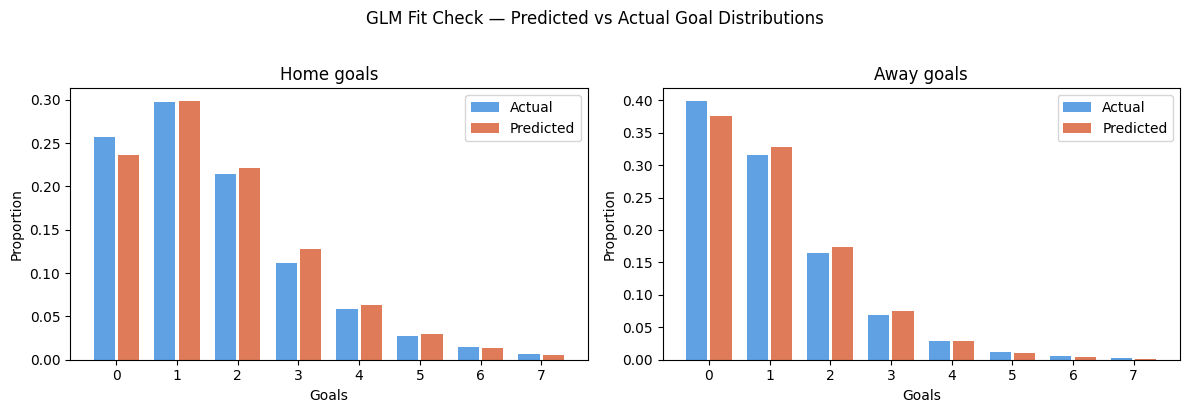

Saved: glm_fit_check.png


In [29]:
# Fit check — predicted vs actual goal distributions
# If the model is well calibrated, the predicted goal distribution
# should closely match the actual distribution.
# Bars should sit almost on top of each other.
# Key thing to watch: does the model get 0-goal frequency right?
# Pure Poisson tends to underpredict 0-0 — Dixon-Coles should fix this.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, score_col, lam_col, label in [
    (axes[0], 'home_score', 'lambda_home_glm', 'Home goals'),
    (axes[1], 'away_score', 'lambda_away_glm', 'Away goals')
]:
    actual = df_model_v2[score_col].value_counts(normalize=True).sort_index()

    max_g = 7
    pred = np.zeros(max_g + 1)
    for k in range(max_g + 1):
        pred[k] = df_model_v2[lam_col].apply(lambda l: poisson.pmf(k, l)).mean()

    x = np.arange(max_g + 1)
    ax.bar(x - 0.2, [actual.get(i, 0) for i in x], width=0.35,
           label='Actual', color='#378ADD', alpha=0.8)
    ax.bar(x + 0.2, pred, width=0.35,
           label='Predicted', color='#D85A30', alpha=0.8)
    ax.set_xlabel('Goals')
    ax.set_ylabel('Proportion')
    ax.set_title(label)
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.suptitle('GLM Fit Check — Predicted vs Actual Goal Distributions', y=1.02)
plt.tight_layout()
plt.savefig(
    Path.home() / 'wc2026/notebooks/glm_fit_check.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: glm_fit_check.png")

In [30]:
print("df:          ", df.shape)
print("df_model:    ", df_model.shape)
print("df_model_v2: ", df_model_v2.shape)

df:           (25319, 22)
df_model:     (24818, 23)
df_model_v2:  (24715, 28)


In [31]:
# Find real upsets in recent data 
# An upset = large Elo favourite lost or drew
# We look for matches where elo_diff > 300 (strong favourite)
# but the underdog won or drew

upsets = df_model_v2[
    (df_model_v2['date'] >= '2018-01-01') &  # recent era only
    (
        # Strong home favourite lost or drew
        ((df_model_v2['elo_diff'] > 300) & (df_model_v2['home_score'] <= df_model_v2['away_score'])) |
        # Strong away favourite lost or drew  
        ((df_model_v2['elo_diff'] < -300) & (df_model_v2['away_score'] <= df_model_v2['home_score']))
    )
][['date','home_team','away_team','home_score','away_score',
   'elo_diff','tournament','lambda_home_glm','lambda_away_glm',
   'home_win','draw','away_win']].sort_values('elo_diff', ascending=False)

print(f"Upsets found: {len(upsets)}")
print(upsets.head(20).to_string(index=False))

Upsets found: 241
      date    home_team           away_team  home_score  away_score  elo_diff                           tournament  lambda_home_glm  lambda_away_glm  home_win   draw  away_win
2019-09-08       Greece       Liechtenstein         1.0         1.0     679.5              UEFA Euro qualification         5.076336         0.280347    0.9809 0.0168    0.0023
2024-06-07      Romania       Liechtenstein         0.0         0.0     593.6                             Friendly         5.292503         0.246186    0.9852 0.0132    0.0016
2021-03-30       Turkey              Latvia         3.0         3.0     565.2         FIFA World Cup qualification         4.422995         0.297539    0.9670 0.0285    0.0045
2023-03-28       Kosovo             Andorra         1.0         1.0     530.9              UEFA Euro qualification         3.617120         0.367619    0.9292 0.0585    0.0123
2021-11-13       Norway              Latvia         0.0         0.0     524.5         FIFA World Cup q

In [32]:
#  Spot check — Argentina vs Iceland, World Cup 2018 
# Real upset — Iceland held Argentina to 1-1 at the 2018 World Cup group stage
# Argentina Elo ~2050, Iceland Elo ~1565, Elo diff ~484
# Our model gave Argentina 75.7% win probability before the match

# Pull the actual match from our data
match = df_model_v2[
    (df_model_v2['home_team'] == 'Argentina') &
    (df_model_v2['away_team'] == 'Iceland') &
    (df_model_v2['date'].dt.year == 2018)
].iloc[0]

lh = match['lambda_home_glm']
la = match['lambda_away_glm']

# Build scoreline matrix
mat = scoreline_matrix(lh, la)
probs = match_probabilities(lh, la)

print("Argentina vs Iceland — World Cup 2018")
print(f"  Elo diff:          {match['elo_diff']:.1f}")
print(f"  λ_home (Argentina): {lh:.3f}")
print(f"  λ_away (Iceland):   {la:.3f}")
print(f"\n  Argentina win: {probs['home_win']:.1%}")
print(f"  Draw:          {probs['draw']:.1%}")
print(f"  Iceland win:   {probs['away_win']:.1%}")
print(f"\n  Top 5 most likely scorelines:")
for prob, i, j in probs['top_scorelines']:
    print(f"    {i}-{j}: {prob:.2%}")

# Actual result
print(f"\n  Actual result: {int(match['home_score'])}-{int(match['away_score'])} ← UPSET")
print(f"  P(actual 1-1): {mat[1,1]:.2%}")

Argentina vs Iceland — World Cup 2018
  Elo diff:          484.9
  λ_home (Argentina): 2.424
  λ_away (Iceland):   0.655

  Argentina win: 75.7%
  Draw:          16.9%
  Iceland win:   7.4%

  Top 5 most likely scorelines:
    2-0: 13.52%
    3-0: 10.92%
    1-0: 10.43%
    2-1: 8.86%
    1-1: 8.05%

  Actual result: 1-1 ← UPSET
  P(actual 1-1): 8.05%


In [33]:
#  Save models and predictions 
# Save the fitted GLM objects for reuse in Notebook 4 (Monte Carlo simulator)
# and the training predictions for calibration and XGBoost comparison.

import pickle

models_dir    = Path.home() / 'wc2026' / 'models'
processed_dir = Path.home() / 'wc2026' / 'data' / 'processed'

# Create models directory if it doesn't exist
models_dir.mkdir(parents=True, exist_ok=True)

# Save GLM model objects
with open(models_dir / 'glm_home_v2.pkl', 'wb') as f:
    pickle.dump(glm_home_v2, f)

with open(models_dir / 'glm_away_v2.pkl', 'wb') as f:
    pickle.dump(glm_away_v2, f)

# Save training predictions
df_model_v2.to_csv(processed_dir / 'training_predictions_glm.csv', index=False)

# Save feature list for consistency across notebooks
with open(models_dir / 'features_v2.pkl', 'wb') as f:
    pickle.dump(FEATURES_V2, f)

print("Saved:")
print(f"  {models_dir}/glm_home_v2.pkl")
print(f"  {models_dir}/glm_away_v2.pkl")
print(f"  {models_dir}/features_v2.pkl")
print(f"  {processed_dir}/training_predictions_glm.csv")

print(f"\nModel summary:")
print(f"  Training rows:   {len(df_model_v2):,}")
print(f"  Features:        {FEATURES_V2}")
print(f"  Home GLM converged: {glm_home_v2.converged}")
print(f"  Away GLM converged: {glm_away_v2.converged}")
print(f"  Mean λ_home:     {df_model_v2['lambda_home_glm'].mean():.3f}")
print(f"  Mean λ_away:     {df_model_v2['lambda_away_glm'].mean():.3f}")

Saved:
  /home/ubuntu/wc2026/models/glm_home_v2.pkl
  /home/ubuntu/wc2026/models/glm_away_v2.pkl
  /home/ubuntu/wc2026/models/features_v2.pkl
  /home/ubuntu/wc2026/data/processed/training_predictions_glm.csv

Model summary:
  Training rows:   24,715
  Features:        ['elo_diff', 'squad_value_diff', 'home_form', 'away_form', 'home_advantage']
  Home GLM converged: True
  Away GLM converged: True
  Mean λ_home:     1.690
  Mean λ_away:     1.116
